In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

In [129]:
df = pd.read_csv('heart_failure_clinical_records_dataset.csv.xls')
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [130]:
df.DEATH_EVENT.value_counts()

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

C:\Users\danie\AppData\Local\Temp\ipykernel_12456\2574474611.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df['DEATH_EVENT'], palette='Set1')


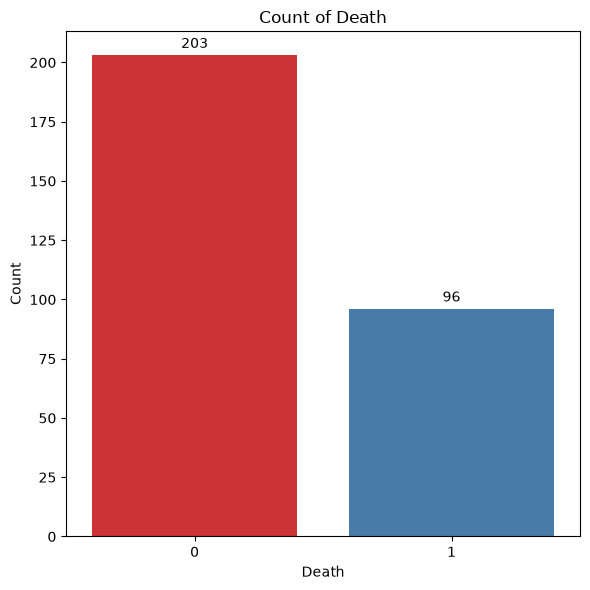

In [131]:
plt.figure(figsize=(6, 6))
ax = sns.countplot(x=df['DEATH_EVENT'], palette='Set1')
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.title('Count of Death')
plt.xlabel('Death')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

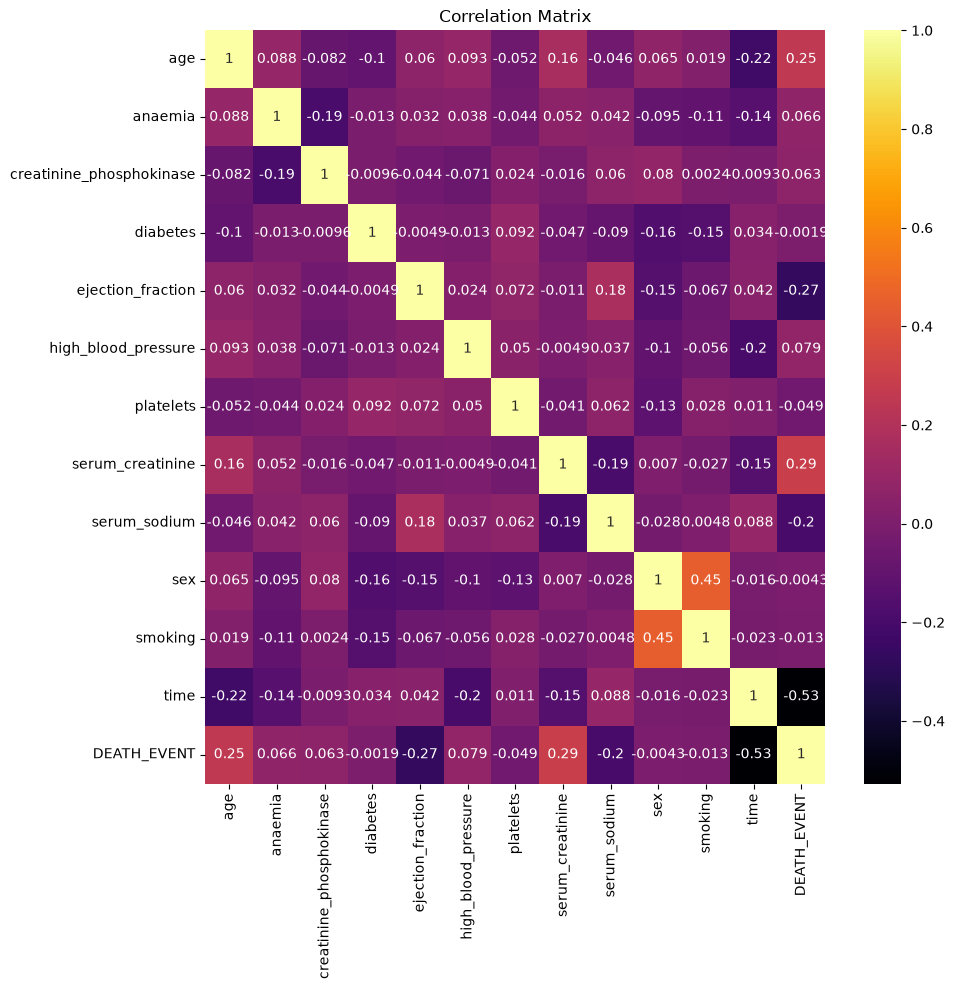

In [132]:
correl_matrix = df.corr()

plt.figure(figsize=(10, 10))
sns.heatmap(correl_matrix, cmap='inferno', annot=True, fmt='.2g')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'The interaction of Serum Sodium and Serum Creatinin regarding the Death')

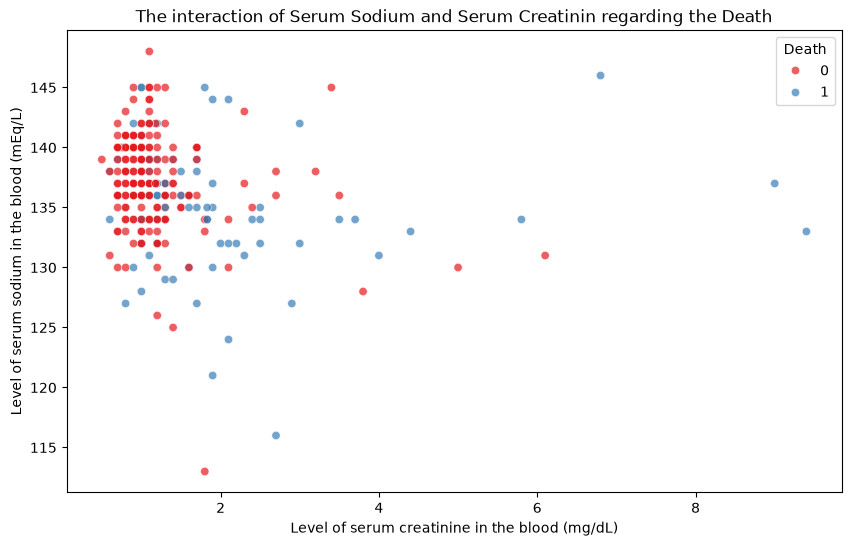

In [133]:
x_data = df['serum_creatinine']
y_data = df['serum_sodium']
target = df['DEATH_EVENT']

plt.figure(figsize=(10, 6))
ax = sns.scatterplot(data=df, x=x_data, y=y_data, hue=target, palette='Set1', alpha=0.7)
ax.legend_.set_title('Death')
plt.ylabel('Level of serum sodium in the blood (mEq/L)')
plt.xlabel('Level of serum creatinine in the blood (mg/dL)')
plt.title('The interaction of Serum Sodium and Serum Creatinin regarding the Death')

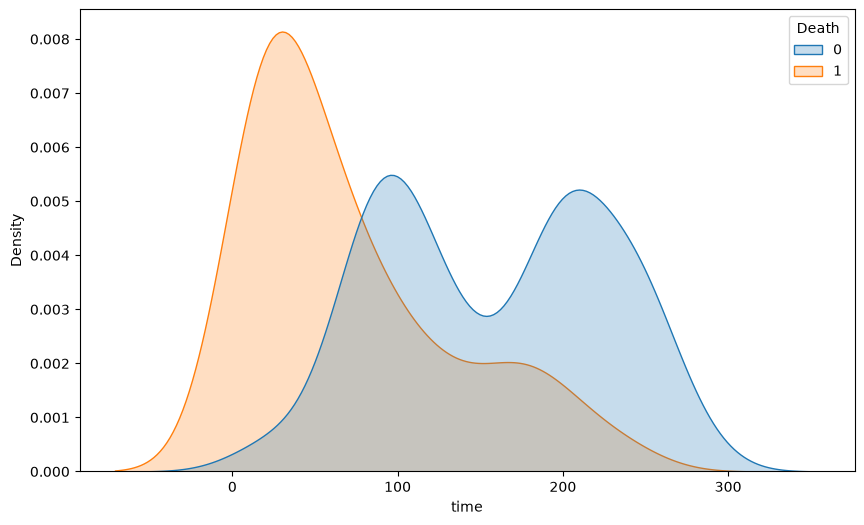

In [134]:
plt.figure(figsize=(10, 6))
ax = sns.kdeplot(data=df, x=df['time'], hue=df['DEATH_EVENT'], fill=True, common_norm=False)
ax.legend_.set_title('Death')
plt.show()

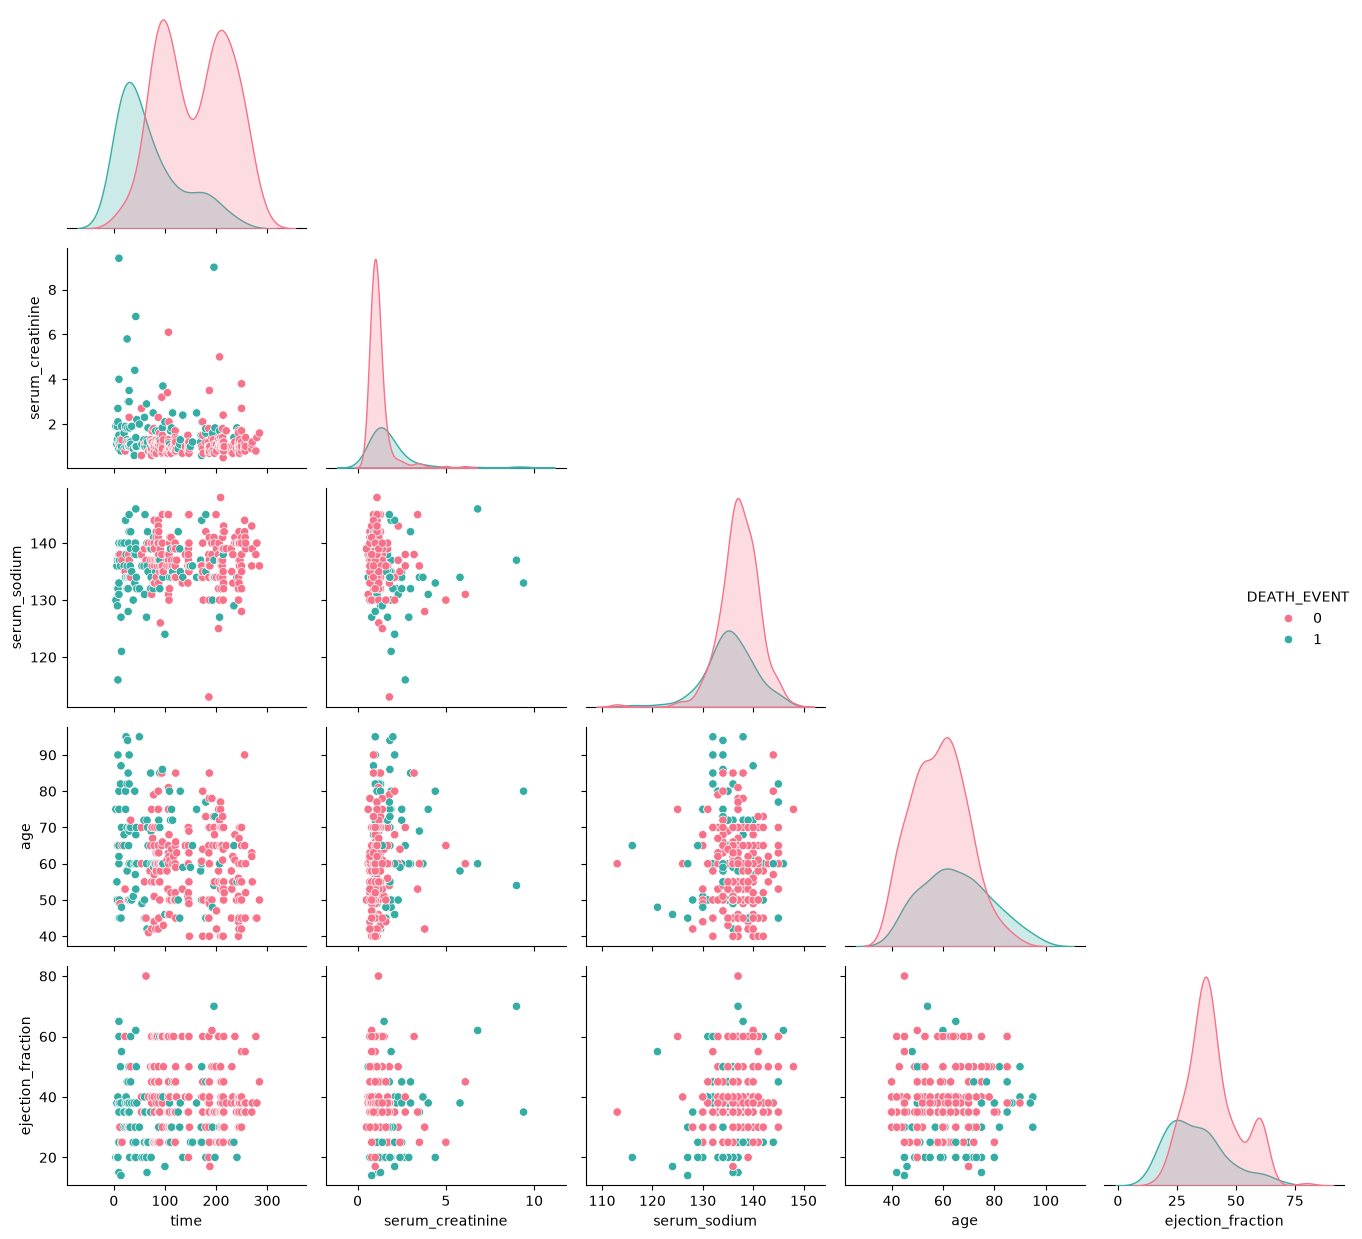

In [135]:
columns = ['time', 'serum_creatinine', 'serum_sodium', 'age', 'ejection_fraction', 'DEATH_EVENT']
sns.pairplot(df[columns], hue='DEATH_EVENT',corner=True,palette='husl', height=2.5)
plt.tight_layout()


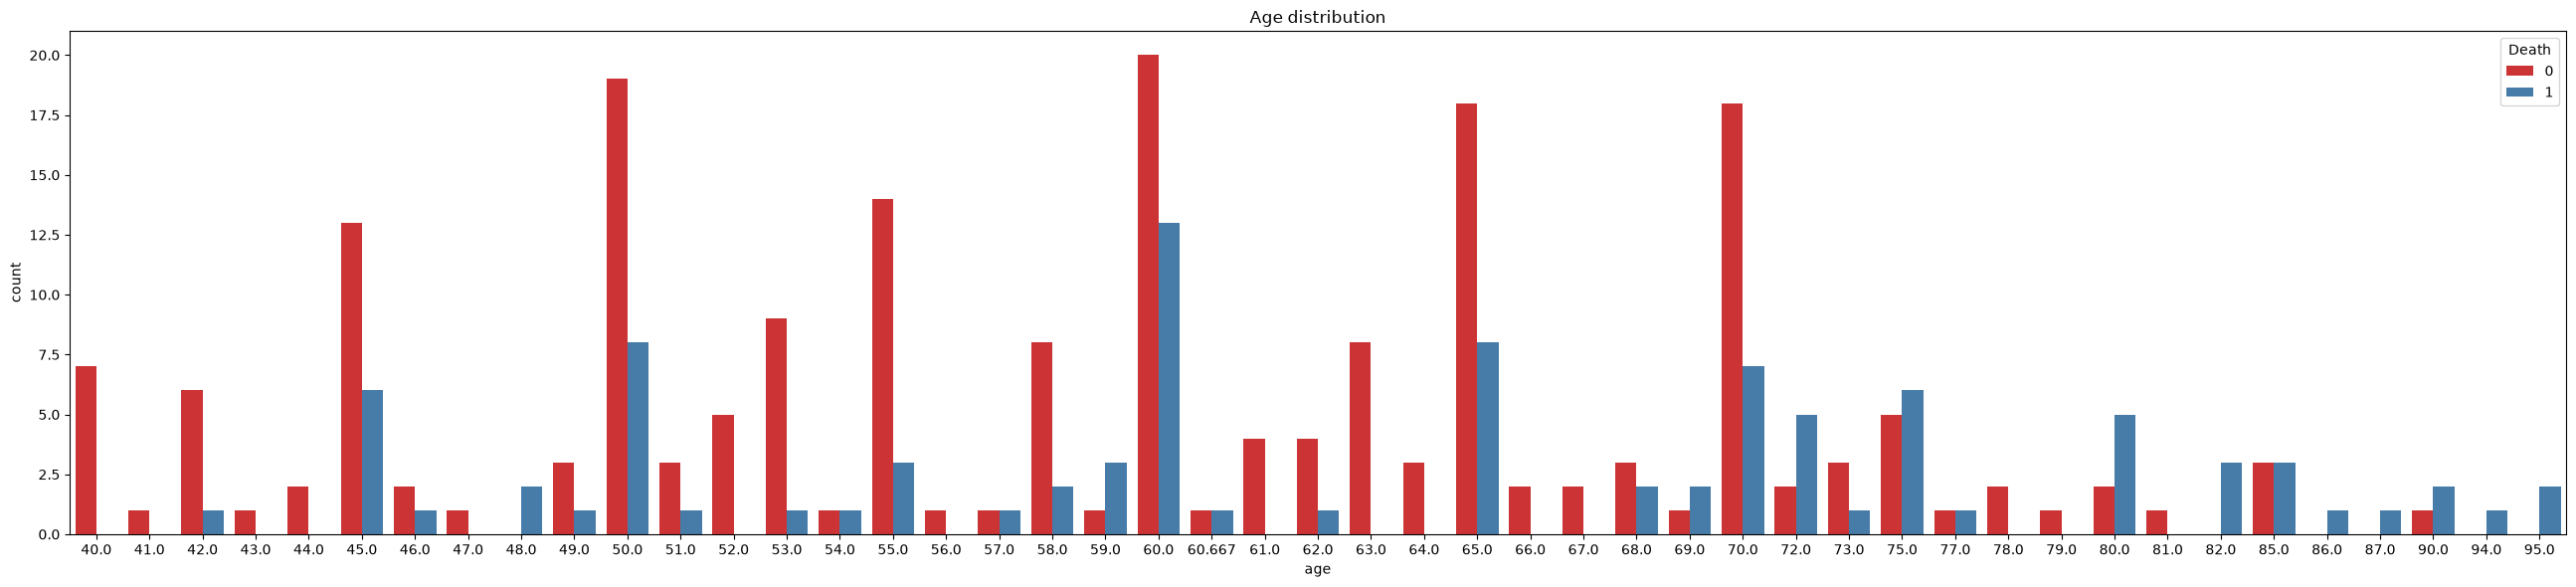

In [136]:
plt.figure(figsize=(26, 6))
ax = sns.countplot(data=df, x=df['age'], hue='DEATH_EVENT', palette='Set1')
ax.legend_.set_title('Death')
plt.title('Age distribution')
plt.tight_layout()

In [137]:
quality_report = {
    'total_records': len(df),
    'duplicate_rows': df.duplicated().sum(),
    'missing_values': df.isnull().sum().to_dict(),
}
pd.DataFrame(quality_report)

,total_records,duplicate_rows,missing_values
age,299,0,0
anaemia,299,0,0
creatinine_phosphokinase,299,0,0
diabetes,299,0,0
ejection_fraction,299,0,0
high_blood_pressure,299,0,0
platelets,299,0,0
serum_creatinine,299,0,0
serum_sodium,299,0,0
sex,299,0,0


In [138]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


In [139]:
preprocessor = ColumnTransformer(
    transformers=[
        ('std', StandardScaler(), ['age', 'creatinine_phosphokinase', 'ejection_fraction', 'platelets', 'serum_creatinine', 'serum_sodium', 'time'])
    ],
    remainder='passthrough'
)
preprocessor.set_output(transform='pandas')

X = df.copy().drop(columns=['DEATH_EVENT'])
y = df.copy()['DEATH_EVENT']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train = preprocessor.fit_transform(X_train, y_train)
X_test = preprocessor.transform(X_test)
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
std__age,239.0,4.533798e-16,1.002099,-1.845246,-0.838232,-0.093917,0.737964,2.970908
std__creatinine_phosphokinase,239.0,3.716228e-17,1.002099,-0.573912,-0.480865,-0.346244,-0.020580,7.184619
std__ejection_fraction,239.0,1.913857e-16,1.002099,-1.912094,-0.658921,0.009438,0.594252,3.518322
std__platelets,239.0,-5.574342e-16,1.002099,-2.404893,-0.515821,-0.003150,0.401498,5.910452
std__serum_creatinine,239.0,-4.831096e-17,1.002099,-0.820512,-0.452452,-0.268422,0.007623,7.368825
std__serum_sodium,239.0,2.883328e-15,1.002099,-5.327248,-0.572231,0.107057,0.559915,2.597779
std__time,239.0,1.858114e-18,1.002099,-1.591685,-0.745577,-0.196576,0.907886,1.973595
remainder__anaemia,239.0,4.476987e-01,0.498301,0.000000,0.000000,0.000000,1.000000,1.000000
remainder__diabetes,239.0,4.476987e-01,0.498301,0.000000,0.000000,0.000000,1.000000,1.000000
remainder__high_blood_pressure,239.0,3.723849e-01,0.484455,0.000000,0.000000,0.000000,1.000000,1.000000


In [140]:
model = LogisticRegression(C=0.1, class_weight='balanced')

model.fit(X_train, y_train)
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = np.where(y_prob > 0.25, 1, 0)
y_pred

array([0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1])

In [141]:
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 score': f1_score(y_test, y_pred)
}
df_metrics = pd.DataFrame(metrics, index=['Value']) 
display(df_metrics.T)

,Value
Accuracy,0.683333
Precision,0.500000
Recall,0.947368
F1 score,0.654545


Text(42.722222222222214, 0.5, 'True Positive Rate')

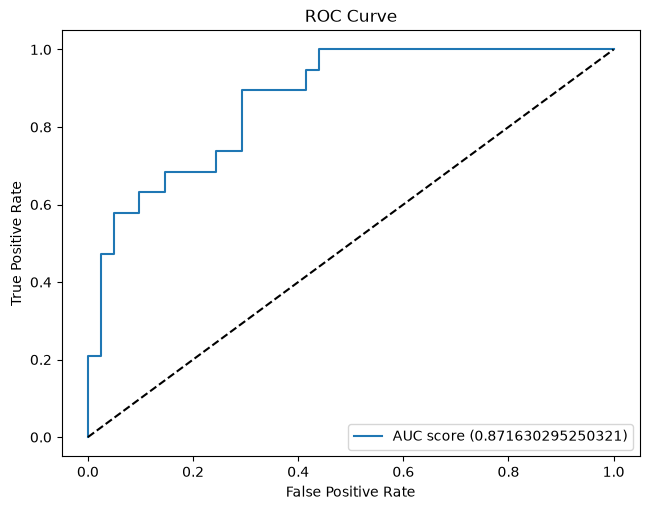

In [142]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label=f'AUC score ({roc_auc_score(y_test, y_prob)})')
plt.plot([0, 1], [0, 1], 'k--')
plt.legend()
plt.tight_layout()
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')